In [31]:
# Step 1 — Load Data, Select Race, Filter Drivers
import logging
from pathlib import Path

import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

DATA_DIR = Path("data")        
RACE_YEAR = 2013
RACE_NAME_SUBSTR = "Spanish"   
MIN_DRIVERS, MAX_DRIVERS = 5, 10


In [32]:
def load_f1_data(data_dir: Path = DATA_DIR) -> dict[str, pd.DataFrame]:
    """Load only the 4 CSVs this project needs. status.csv is deliberately
    excluded: results.csv['position'] already tells us who finished
    (see get_finished_drivers), so a 5th file and a join add nothing."""
    needed = ["lap_times", "pit_stops", "results", "races"]
    return {name: pd.read_csv(data_dir / f"{name}.csv") for name in needed}


In [33]:
def select_race(races: pd.DataFrame, year: int, name_substr: str) -> int:
    """Look up raceId by year + partial name rather than hardcoding a
    numeric ID. IDs can differ across dataset snapshots, and a wrong
    hardcoded ID would fail silently -- this fails loudly instead if the
    match isn't unique."""
    match = races[
        (races["year"] == year)
        & (races["name"].str.contains(name_substr, case=False))
    ]
    if len(match) != 1:
        raise ValueError(
            f"Expected exactly 1 race for {year} '{name_substr}', found {len(match)}"
        )
    race_id = int(match.iloc[0]["raceId"])
    logger.info("Selected raceId=%d (%s %d)", race_id, match.iloc[0]["name"], year)
    return race_id


In [34]:
def get_finished_drivers(
    results: pd.DataFrame,
    race_id: int,
    min_drivers: int = MIN_DRIVERS,
    max_drivers: int = MAX_DRIVERS,
) -> pd.DataFrame:
    """Classified finishers for this race, capped at max_drivers by final
    position. 'Finished' is derived from results['position'].notna() --
    Ergast only populates numeric `position` for classified finishers,
    leaving it NaN for DNF/DSQ/DNS. That's the same information status.csv
    would give us, without loading a 5th file.

    Keeps 'grid' here too: it's needed later for the baseline model, and
    it comes from this same results.csv row -- no reason to re-filter
    results.csv again in Step 4."""
    race_results = results[results["raceId"] == race_id]
    finished = race_results[race_results["position"].notna()].sort_values("positionOrder")

    if len(finished) < min_drivers:
        raise ValueError(
            f"Only {len(finished)} finishers in race {race_id}, need >= {min_drivers}. "
            "Pick a different race."
        )

    keep_cols = ["driverId", "grid", "positionOrder"]
    selected = finished.head(max_drivers)[keep_cols].reset_index(drop=True)
    logger.info("Selected %d finishers: %s", len(selected), selected["driverId"].tolist())
    return selected


In [35]:
def get_race_laps(lap_times: pd.DataFrame, race_id: int, driver_ids: list[int]) -> pd.DataFrame:
    """Subset lap_times to this race + driver pool, and add lap_time_sec --
    every downstream metric and plot expects seconds, not milliseconds, so
    the conversion happens once, here, at the source."""
    laps = lap_times[
        (lap_times["raceId"] == race_id) & (lap_times["driverId"].isin(driver_ids))
    ].copy()
    laps["lap_time_sec"] = laps["milliseconds"] / 1000.0
    return laps.sort_values(["driverId", "lap"]).reset_index(drop=True)


def get_race_pit_stops(pit_stops: pd.DataFrame, race_id: int, driver_ids: list[int]) -> pd.DataFrame:
    """Subset pit_stops to this race + driver pool. Needed by both the
    Step 2 cleaning pass (in-lap/out-lap removal) and Step 3 feature
    engineering (stint boundaries)."""
    return pit_stops[
        (pit_stops["raceId"] == race_id) & (pit_stops["driverId"].isin(driver_ids))
    ].sort_values(["driverId", "lap"]).reset_index(drop=True)


In [36]:
# Run Step 1
data = load_f1_data()

race_id = select_race(data["races"], RACE_YEAR, RACE_NAME_SUBSTR)
driver_info = get_finished_drivers(data["results"], race_id)
driver_ids = driver_info["driverId"].tolist()

laps = get_race_laps(data["lap_times"], race_id, driver_ids)
pit_stops = get_race_pit_stops(data["pit_stops"], race_id, driver_ids)

print(f"raceId           : {race_id}")
print(f"drivers kept ({len(driver_ids)}) : {driver_ids}")
print(f"raw laps kept     : {len(laps)}")
print(f"pit stops kept    : {len(pit_stops)}")
print("\nLaps per driver:")
print(laps['driverId'].value_counts().sort_index())

print("\nLowest-variance laps (possible SC/VSC if near-zero):")
print(laps.groupby("lap")["lap_time_sec"].std().sort_values().head(5))


INFO | Selected raceId=884 (Spanish Grand Prix 2013)
INFO | Selected 10 finishers: [4, 8, 13, 20, 17, 3, 814, 18, 815, 817]


raceId           : 884
drivers kept (10) : [4, 8, 13, 20, 17, 3, 814, 18, 815, 817]
raw laps kept     : 659
pit stops kept    : 37

Laps per driver:
driverId
3      66
4      66
8      66
13     66
17     66
18     66
20     66
814    66
815    66
817    65
Name: count, dtype: int64

Lowest-variance laps (possible SC/VSC if near-zero):
lap
3     0.282935
5     0.299198
4     0.325347
6     0.393925
55    0.479131
Name: lap_time_sec, dtype: float64


In [37]:
# Step 2 — Data Cleaning
def remove_pit_transition_laps(
    laps: pd.DataFrame, pit_stops: pd.DataFrame
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Drop each driver's in-lap (pit_stops['lap']) and out-lap
    (pit_stops['lap'] + 1). Built per-driver: pit lap numbers only mean
    something relative to that driver's own race."""
    in_lap_keys, out_lap_keys = set(), set()
    for _, stop in pit_stops.iterrows():
        driver, pit_lap = int(stop["driverId"]), int(stop["lap"])
        in_lap_keys.add((driver, pit_lap))
        out_lap_keys.add((driver, pit_lap + 1))

    lap_keys = list(zip(laps["driverId"], laps["lap"]))
    is_in_lap = np.array([k in in_lap_keys for k in lap_keys])
    is_out_lap = np.array([k in out_lap_keys for k in lap_keys])

    counts = {
        "in_laps_removed": int(is_in_lap.sum()),
        "out_laps_removed": int((is_out_lap & ~is_in_lap).sum()),  # avoid double-count
    }
    cleaned = laps.loc[~(is_in_lap | is_out_lap)].copy()
    return cleaned, counts


In [38]:
def remove_slow_outlier_laps(
    laps: pd.DataFrame, threshold_multiplier: float = 1.5
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Drop laps slower than `threshold_multiplier` x each driver's own
    median lap_time_sec. Per-driver (not field-wide): raw pace differs by
    car, so a shared threshold would unfairly flag a slower car's entirely
    normal laps."""
    median_by_driver = laps.groupby("driverId")["lap_time_sec"].transform("median")
    is_slow = laps["lap_time_sec"] > threshold_multiplier * median_by_driver

    counts = {"slow_laps_removed": int(is_slow.sum())}
    cleaned = laps.loc[~is_slow].copy()
    return cleaned, counts


In [39]:
def clean_race_laps(
    laps: pd.DataFrame, pit_stops: pd.DataFrame, threshold_multiplier: float = 1.5
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Orchestrates both passes, returns cleaned laps + a single drop-count log."""
    raw_count = len(laps)

    laps, pit_counts = remove_pit_transition_laps(laps, pit_stops)
    laps, slow_counts = remove_slow_outlier_laps(laps, threshold_multiplier)

    log = {
        "raw_laps": raw_count,
        **pit_counts,
        **slow_counts,
        "clean_laps": len(laps),
    }
    log["total_removed"] = raw_count - len(laps)
    return laps.reset_index(drop=True), log


In [40]:
# Run Step 2 
clean_laps, cleaning_log = clean_race_laps(laps, pit_stops)

print("=== Cleaning Log ===")
for key, value in cleaning_log.items():
    print(f"  {key:20s}: {value}")

print(f"\nRemoved {cleaning_log['total_removed']} of {cleaning_log['raw_laps']} "
      f"raw laps ({cleaning_log['total_removed'] / cleaning_log['raw_laps']:.1%}).")
print(f"Remaining laps per driver:")
print(clean_laps['driverId'].value_counts().sort_index())


=== Cleaning Log ===
  raw_laps            : 659
  in_laps_removed     : 37
  out_laps_removed    : 37
  slow_laps_removed   : 0
  clean_laps          : 585
  total_removed       : 74

Removed 74 of 659 raw laps (11.2%).
Remaining laps per driver:
driverId
3      60
4      58
8      60
13     58
17     58
18     60
20     58
814    58
815    58
817    57
Name: count, dtype: int64


In [41]:
# Step 3 — Feature Engineering & Chronological Stint Split
def compute_stint_features(laps: pd.DataFrame, pit_stops: pd.DataFrame) -> pd.DataFrame:
    """Adds stint_number and tire_age, computed per driver from that
    driver's own pit-stop laps."""
    laps = laps.copy()
    laps["stint_number"] = 1
    laps["tire_age"] = laps["lap"]

    for driver_id, group in laps.groupby("driverId"):
        pit_laps = np.array(
            sorted(pit_stops.loc[pit_stops["driverId"] == driver_id, "lap"].tolist())
        )
        lap_numbers = group["lap"].to_numpy()

        # idx = how many pit stops have happened at or before each lap
        idx = np.searchsorted(pit_laps, lap_numbers, side="right")
        stint_number = idx + 1

        most_recent_pit = np.zeros_like(lap_numbers)
        for i, k in enumerate(idx):
            if k > 0:
                most_recent_pit[i] = pit_laps[k - 1]
        tire_age = lap_numbers - most_recent_pit

        laps.loc[group.index, "stint_number"] = stint_number
        laps.loc[group.index, "tire_age"] = tire_age

    return laps


def train_test_stint_split(laps_with_features: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Per-driver chronological split: final stint -> test, earlier stints -> train."""
    max_stint = laps_with_features.groupby("driverId")["stint_number"].transform("max")
    is_test = laps_with_features["stint_number"] == max_stint

    train_df = laps_with_features.loc[~is_test].reset_index(drop=True)
    test_df = laps_with_features.loc[is_test].reset_index(drop=True)
    return train_df, test_df


In [42]:
# Run Step 3 
featured_laps = compute_stint_features(clean_laps, pit_stops)
featured_laps = featured_laps.merge(driver_info[["driverId", "grid"]], on="driverId", how="left")

train_df, test_df = train_test_stint_split(featured_laps)

print(f"Train laps: {len(train_df)}   Test laps: {len(test_df)}")
print(f"\nMax stint per driver:")
print(featured_laps.groupby("driverId")["stint_number"].max().sort_index())
print(f"\nSample of engineered features:")
featured_laps[["driverId", "lap", "stint_number", "tire_age", "grid", "lap_time_sec"]].head(10)


Train laps: 429   Test laps: 156

Max stint per driver:
driverId
3      4
4      5
8      4
13     5
17     5
18     4
20     5
814    5
815    5
817    5
Name: stint_number, dtype: int64

Sample of engineered features:


,driverId,lap,stint_number,tire_age,grid,lap_time_sec
0,3,1,1,1,1,94.590
1,3,2,1,2,1,91.123
2,3,3,1,3,1,91.188
3,3,4,1,4,1,90.671
4,3,5,1,5,1,91.064
5,3,6,1,6,1,90.879
6,3,7,1,7,1,91.140
7,3,8,1,8,1,90.789
8,3,9,1,9,1,90.943
9,3,12,2,2,1,90.241


In [43]:
# Step 4 & 5 — Model Training, Comparison, and Metrics
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

TARGET = "lap_time_sec"
BASELINE_FEATURES = ["grid", "lap"]
ENHANCED_FEATURES = ["tire_age", "grid", "lap", "stint_number"]

ALGORITHMS = {
    "Ridge": lambda: Ridge(alpha=1.0, random_state=42),
    "RandomForest": lambda: RandomForestRegressor(
        n_estimators=200, max_depth=5, min_samples_leaf=3, random_state=42
    ),
}

FEATURE_SETS = {
    "Baseline (grid, lap)": BASELINE_FEATURES,
    "Enhanced (tire_age, grid, lap, stint_number)": ENHANCED_FEATURES,
}


def rmse(y_true, y_pred) -> float:
    # np.sqrt(mean_squared_error(...)) instead of squared=False, which was
    # removed in newer scikit-learn -- this is version-proof.
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mae(y_true, y_pred) -> float:
    return float(mean_absolute_error(y_true, y_pred))


In [44]:
# Run Step 4: train all 4 combinations 
results_table = []
fitted_models = {}      # (algo_name, feature_set_name) -> fitted model
predictions = {}        # (algo_name, feature_set_name) -> np.ndarray of test predictions

for algo_name, algo_factory in ALGORITHMS.items():
    for fset_name, features in FEATURE_SETS.items():
        model = algo_factory()
        model.fit(train_df[features], train_df[TARGET])
        preds = model.predict(test_df[features])

        results_table.append({
            "Algorithm": algo_name,
            "Feature Set": fset_name,
            "RMSE (s)": round(rmse(test_df[TARGET], preds), 3),
            "MAE (s)": round(mae(test_df[TARGET], preds), 3),
        })
        fitted_models[(algo_name, fset_name)] = model
        predictions[(algo_name, fset_name)] = preds

metrics_df = pd.DataFrame(results_table)
metrics_df


,Algorithm,Feature Set,RMSE (s),MAE (s)
0,Ridge,"Baseline (grid, lap)",1.238,0.963
1,Ridge,"Enhanced (tire_age, grid, lap, stint_number)",1.218,0.961
2,RandomForest,"Baseline (grid, lap)",1.531,1.338
3,RandomForest,"Enhanced (tire_age, grid, lap, stint_number)",1.286,1.096


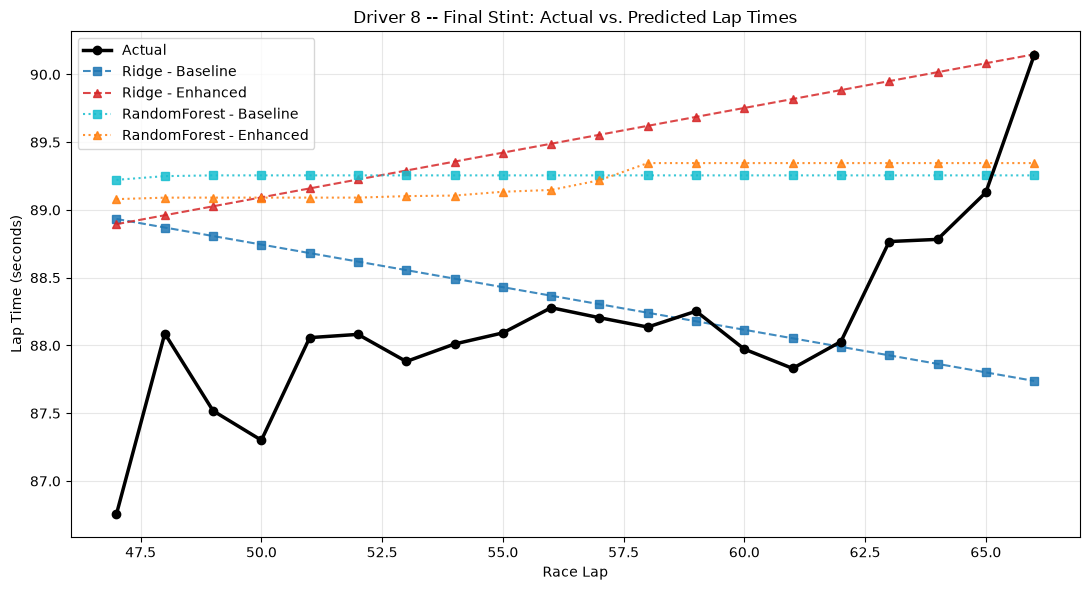

In [45]:
# Step 6 — Visualization: Actual vs. Predicted, Final Stint
import matplotlib.pyplot as plt

target_driver = int(test_df["driverId"].value_counts().idxmax())
mask = (test_df["driverId"] == target_driver).to_numpy()

driver_laps = test_df.loc[mask, "lap"].to_numpy()
actual = test_df.loc[mask, TARGET].to_numpy()
order = np.argsort(driver_laps)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(driver_laps[order], actual[order], "o-", color="black",
        linewidth=2.5, label="Actual", zorder=5)

style_map = {
    ("Ridge", "Baseline (grid, lap)"): dict(color="tab:blue", marker="s", ls="--"),
    ("Ridge", "Enhanced (tire_age, grid, lap, stint_number)"): dict(color="tab:red", marker="^", ls="--"),
    ("RandomForest", "Baseline (grid, lap)"): dict(color="tab:cyan", marker="s", ls=":"),
    ("RandomForest", "Enhanced (tire_age, grid, lap, stint_number)"): dict(color="tab:orange", marker="^", ls=":"),
}

for (algo_name, fset_name), style in style_map.items():
    preds = predictions[(algo_name, fset_name)][mask][order]
    label = f"{algo_name} - {'Enhanced' if 'Enhanced' in fset_name else 'Baseline'}"
    ax.plot(driver_laps[order], preds, linewidth=1.5, alpha=0.85, label=label, **style)

ax.set_xlabel("Race Lap")
ax.set_ylabel("Lap Time (seconds)")
ax.set_title(f"Driver {target_driver} -- Final Stint: Actual vs. Predicted Lap Times")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("lap_time_comparison.png", dpi=150)
plt.show()
